<a href="https://colab.research.google.com/github/AthithepSuksupsri/229352_Stat-learning-for-data-sci/blob/main/Lab09_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #9

[Recipe for Training Neural Networks](https://karpathy.github.io/2019/04/25/recipe/)

In [1]:
%%capture
!git clone https://github.com/donlapark/ds352-labs.git

In [2]:
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

## Training a neural network in PyTorch

### Chihuahua or Muffin?

<center><img src="https://donlapark.pages.dev/229352/lab09-preview.jpg" width="500"/></center>

### 1. Data preparation

#### Load images, resize them to 128x128, and normalize the pixels to be in 0 - 1 range

In [3]:
transform = transforms.Compose([transforms.Resize((128, 128)),
                                transforms.ToTensor()])  # transform pixels to be in 0 - 1 range

dataset = datasets.ImageFolder(root="ds352-labs/lab09-data/train",
                                         transform=transform)

#### Split the dataset into training (80%), validation (20%)

In [4]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

#### Load the datasets into DataLoader

In [5]:
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=10,
                          shuffle=True)
val_loader = DataLoader(dataset=val_dataset,
                        batch_size=len(val_dataset),
                        shuffle=False)

#### Do the same for the test images

In [6]:
test_dataset = datasets.ImageFolder(root="ds352-labs/lab09-data/test",
                                    transform=transform)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=len(test_dataset),
                         shuffle=False)

#### Looking at the first minibatch

In [7]:
train_batches = iter(train_loader)
X, y = next(train_batches)

print(X.shape)  # (batch_size, channel, height, weight)
print(y.shape)

torch.Size([10, 3, 128, 128])
torch.Size([10])


#### Visualize the first four images in the batch

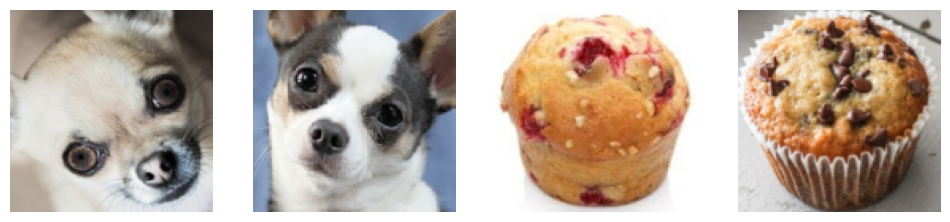

tensor([0, 0, 1, 1])


In [8]:
X = X[:4]  # Select the first 4 images
X = X.numpy().transpose(0, 2, 3, 1)  # Convert from (B, C, H, W) to (B, H, W, C)

# Plot images
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i in range(4):
    axes[i].imshow(X[i])
    axes[i].axis('off')
plt.show()

print(y[:4])

### 2. Build a simple logistic regression

<center><img src="https://donlapark.pages.dev/229352/logistic.png" width="300"/></center>

The most important component of the model class is the `__init__` method and the `forward` method.  

[Linear layer in Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)

[Activation functions in PyTorch](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity). The most important ones are [ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html), [Sigmoid](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html), [Softmax](https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html), [Tanh](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html).

In [9]:
class SimpleLogisticRegression(nn.Module):
  # Attribute --> Layers
  def __init__(self):
    super().__init__()
    # Define layers
    self.flatten = nn.Flatten() # คลี่รูปภาพ
    # linear layer
    self.lin1 = nn.Linear(128 * 128 * 3, 100) # input ตัวที่สองมีความยาว 100
    self.act1 = nn.ReLU() # Activation function
    self.lin2 = nn.Linear(100, 50)
    self.act2 = nn.ReLU() # Activation function
    self.lin3 = nn.Linear(50, 1)

# init เชื่อมต่อกันอย่างไรบ้าง
  def forward(self, x):
    # Forward pass ข้อมูลต้องผ่านตังไหนบ้าง
    x = self.flatten(x)
    x = self.lin1(x)
    x = self.act1(x)
    x = self.lin2(x)
    x = self.act2(x)
    x = self.lin3(x)
    return x

### 3. Initialize training components

#### Initialize the model and loss function

[Loss functions in PyTorch](https://pytorch.org/docs/stable/nn.html#loss-functions). Most important ones are [MSE](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html), [Binary cross, entropy](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html), [Categorical cross entropy](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

In [10]:
model = SimpleLogisticRegression()
criterion = nn.CrossEntropyLoss()

#### Manually setting initial weights to zero for demonstration

In [11]:
with torch.no_grad():
  for layer in model.modules():
      if isinstance(layer, nn.Linear):
          layer.weight.zero_()
          layer.bias.zero_()

#### Create two lists to collect training and validation losses

In [12]:
# List to store the loss values for plotting
train_losses = []
val_losses = []

#### Specify the learning rate

In [13]:
learning_rate = 1e-3
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

### 4. Training the model with gradient descent

#### Convert the dataloader into minibatches

In [14]:
X, y = next(train_batches) # X : images, y : labels

#### Make a prediction on the minibatch (Forward pass)

In [15]:
y_hat = model(X)
y = y.to(torch.float32)
# Output ---> vector ---> Scalar
y_hat = y_hat[:, 0]

#y_hat = y_hat[:, 0]
#y = y.to(torch.float32)

#### Calculate the loss function

Recall that `criterion()` is our binary cross-entropy loss (`BCELoss`).

In [16]:
# Compute the loss
train_loss = criterion(y_hat, y)
train_losses.append(train_loss)

In [17]:
train_losses

[tensor(6.9078, grad_fn=<DivBackward1>)]

#### Calculate the gradient (Backward pass)

In [18]:
# Backward pass: compute the gradient of the loss w.r.t. model parameters
train_loss.backward()

In [19]:
model.parameters()

<generator object Module.parameters at 0x7920bce14e40>

#### Perform a gradient descent step

Careful! We must not include this step in the gradient calculation, hence the use of `with torch.no_grad()`.

In [20]:
# Manually update the weights using the gradient descent rule
optimizer.step() # parameter - learning_rate

# Zero the gradients after updating
model.zero_grad()

#### Do the same for the validation set

Careful! Anything in the validation step must not be included in the gradient calculation, hence the use of `with torch.no_grad()`.

In [21]:
with torch.no_grad():
  for X, y in val_loader:
    y_hat = model(X)
    y_hat = y_hat[:, 0]
    y = y.to(torch.float32)
    print(y_hat, y)
    val_loss = criterion(y_hat, y)
    val_losses.append(val_loss.item())

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010,
        0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010,
        0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010]) tensor([1., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 1.,
        0., 0., 0., 1., 1., 1.])


In [22]:
print(train_losses)
print(val_losses)

[tensor(6.9078, grad_fn=<DivBackward1>)]
[38.13664627075195]


#### Combine everything together.

Repeat the previous steps for 20 **epochs** and plot the training and validation losses.

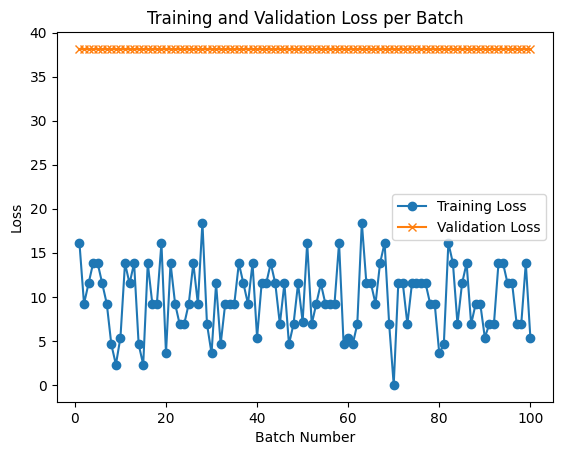

In [23]:
model = SimpleLogisticRegression()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

with torch.no_grad():
  for layer in model.modules():
      if isinstance(layer, nn.Linear):
          layer.weight.zero_()
          layer.bias.zero_()

train_losses = []
val_losses = []

learning_rate = 1e-4

for epoch in range(10):
  for X, y in train_loader:
    y_hat = model(X)
    y_hat = y_hat[:, 0]
    y = y.to(torch.float32)

    loss = criterion(y_hat, y)
    train_losses.append(loss.item())

    loss.backward()
    optimizer.step()

    # Zero the gradients after updating
    model.zero_grad()

    with torch.no_grad():
      for X, y in val_loader:
        y_hat = model(X)
        y_hat = y_hat[:, 0]
        y = y.to(torch.float32)
        val_loss = criterion(y_hat, y)
        val_losses.append(val_loss)

# Plot the training and validation loss
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Training Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, marker='x', label='Validation Loss')
plt.title('Training and Validation Loss per Batch')
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Exercise

In this exercise, we will add more layers to our classification model.

<img src="https://donlapark.pages.dev/229352/lab09-architecture.png" width="450"/>

1. Create a neural network with 3 hidden layers as shown in the picture.

2. Train the model with learning rate = 1e-2, 1e-3, 1e-4, 1e-5, and answer the following questions.
    2.1 What value of learning rate do you **think** is the best? Please explain your reason.
    2.2 What happens to the training losses if your learning rate is too large?
    2.3 What happens to the training losses if your learning rate is too small?

3. After finish training your model. Make the predictions on the test set and compute the accuracy. You may use the provided code below.

4. Use `plt.imshow()` to display at least four images that are incorrectly classified by this model.

In [24]:
# Use this code to calculate test accuracy
with torch.no_grad():
  test_batches = iter(test_loader)
  X, y = next(test_batches)
  y_hat = model(X)
  y_hat = y_hat[:, 0]
  y_hat = (y_hat > 0.5).float()  # the predictions
  ##TODO: compute accuracy


In [26]:
class NewLogisticRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.lin1 = nn.Linear(128 * 128 * 3, 100)
    self.act1 = nn.ReLU()
    self.lin2 = nn.Linear(100, 50)
    self.act2 = nn.ReLU()
    self.lin3 = nn.Linear(50, 25) # Third hidden layer
    self.act3 = nn.ReLU()
    self.lin4 = nn.Linear(25, 1) # Output layer

  def forward(self, x):
    x = self.flatten(x)
    x = self.lin1(x)
    x = self.act1(x)
    x = self.lin2(x)
    x = self.act2(x)
    x = self.lin3(x)
    x = self.act3(x)
    x = self.lin4(x)
    return x

In [27]:
learning_rates = [1e-2, 1e-3, 1e-4, 1e-5]
all_train_losses = {lr: [] for lr in learning_rates}
all_val_losses = {lr: [] for lr in learning_rates}

print(f"Learning rates to experiment with: {learning_rates}")
print(f"Initialized all_train_losses keys: {list(all_train_losses.keys())}")
print(f"Initialized all_val_losses keys: {list(all_val_losses.keys())}")

Learning rates to experiment with: [0.01, 0.001, 0.0001, 1e-05]
Initialized all_train_losses keys: [0.01, 0.001, 0.0001, 1e-05]
Initialized all_val_losses keys: [0.01, 0.001, 0.0001, 1e-05]


In [28]:
num_epochs = 10

for lr in learning_rates:
  print(f"\nTraining with learning rate: {lr}")
  model = NewLogisticRegression()
  # Initialize weights to zero
  with torch.no_grad():
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            layer.weight.zero_()
            layer.bias.zero_()

  criterion = nn.BCEWithLogitsLoss() # Appropriate for binary classification with logits output
  optimizer = optim.AdamW(model.parameters(), lr=lr) # Use AdamW as it's often a good default

  current_train_losses = []
  current_val_losses = []

  for epoch in range(num_epochs):
    model.train() # Set model to training mode
    epoch_train_losses = []
    for X_train, y_train in train_loader:
      # Forward pass
      y_hat_train = model(X_train).squeeze(1) # Squeeze to match y_train shape
      y_train = y_train.to(torch.float32)

      # Calculate loss
      loss = criterion(y_hat_train, y_train)
      epoch_train_losses.append(loss.item())

      # Backward and optimize
      optimizer.zero_grad() # Zero gradients before backward pass
      loss.backward()
      optimizer.step()

    current_train_losses.append(np.mean(epoch_train_losses))

    # Validation step
    model.eval() # Set model to evaluation mode
    epoch_val_losses = []
    with torch.no_grad():
      for X_val, y_val in val_loader:
        y_hat_val = model(X_val).squeeze(1)
        y_val = y_val.to(torch.float32)
        val_loss = criterion(y_hat_val, y_val)
        epoch_val_losses.append(val_loss.item())

    current_val_losses.append(np.mean(epoch_val_losses))

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {current_train_losses[-1]:.4f}, Val Loss: {current_val_losses[-1]:.4f}")

  all_train_losses[lr] = current_train_losses
  all_val_losses[lr] = current_val_losses

print("Training complete for all learning rates.")


Training with learning rate: 0.01
Epoch 1/10, Train Loss: 0.6926, Val Loss: 0.6933
Epoch 2/10, Train Loss: 0.6917, Val Loss: 0.6936
Epoch 3/10, Train Loss: 0.6903, Val Loss: 0.6939
Epoch 4/10, Train Loss: 0.6891, Val Loss: 0.6944
Epoch 5/10, Train Loss: 0.6893, Val Loss: 0.6950
Epoch 6/10, Train Loss: 0.6871, Val Loss: 0.6954
Epoch 7/10, Train Loss: 0.6882, Val Loss: 0.6962
Epoch 8/10, Train Loss: 0.6884, Val Loss: 0.6963
Epoch 9/10, Train Loss: 0.6887, Val Loss: 0.6970
Epoch 10/10, Train Loss: 0.6873, Val Loss: 0.6973

Training with learning rate: 0.001
Epoch 1/10, Train Loss: 0.6931, Val Loss: 0.6931
Epoch 2/10, Train Loss: 0.6929, Val Loss: 0.6932
Epoch 3/10, Train Loss: 0.6928, Val Loss: 0.6932
Epoch 4/10, Train Loss: 0.6925, Val Loss: 0.6932
Epoch 5/10, Train Loss: 0.6926, Val Loss: 0.6932
Epoch 6/10, Train Loss: 0.6921, Val Loss: 0.6932
Epoch 7/10, Train Loss: 0.6921, Val Loss: 0.6932
Epoch 8/10, Train Loss: 0.6919, Val Loss: 0.6932
Epoch 9/10, Train Loss: 0.6917, Val Loss: 0.69

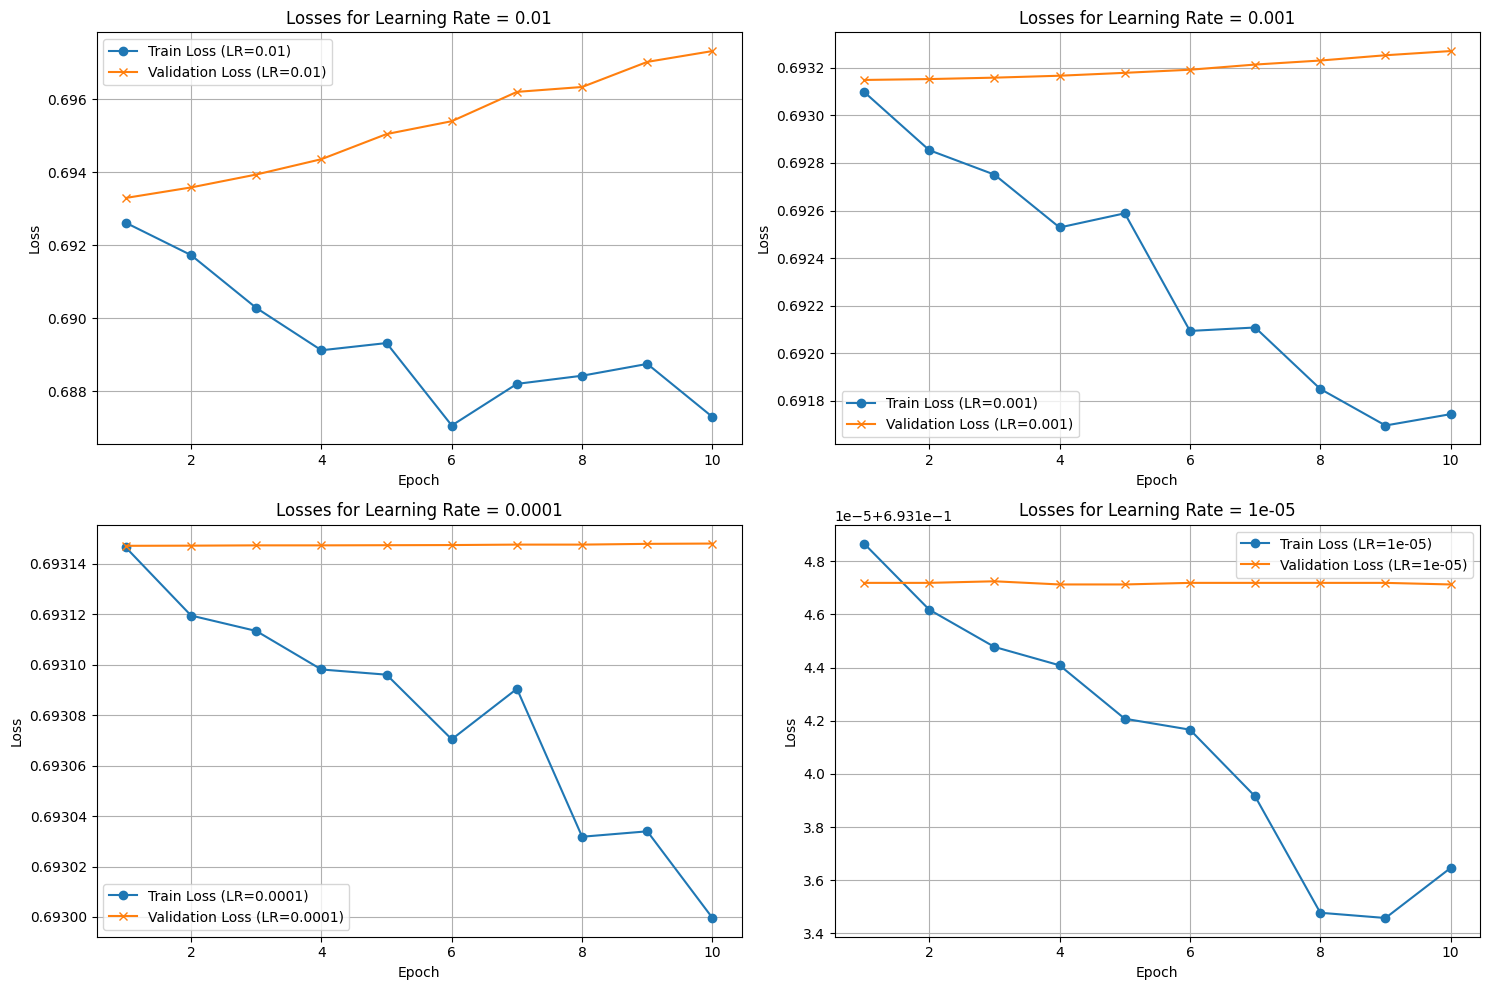

In [29]:
plt.figure(figsize=(15, 10))
for i, lr in enumerate(learning_rates):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of plots
    plt.plot(range(1, num_epochs + 1), all_train_losses[lr], label=f'Train Loss (LR={lr})', marker='o')
    plt.plot(range(1, num_epochs + 1), all_val_losses[lr], label=f'Validation Loss (LR={lr})', marker='x')
    plt.title(f'Losses for Learning Rate = {lr}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()


Training final model with best learning rate: 0.001
Epoch 1/20, Train Loss: 0.6932, Val Loss: 0.6932
Epoch 2/20, Train Loss: 0.6929, Val Loss: 0.6932
Epoch 3/20, Train Loss: 0.6927, Val Loss: 0.6932
Epoch 4/20, Train Loss: 0.6925, Val Loss: 0.6932
Epoch 5/20, Train Loss: 0.6921, Val Loss: 0.6932
Epoch 6/20, Train Loss: 0.6924, Val Loss: 0.6932
Epoch 7/20, Train Loss: 0.6922, Val Loss: 0.6932
Epoch 8/20, Train Loss: 0.6924, Val Loss: 0.6932
Epoch 9/20, Train Loss: 0.6919, Val Loss: 0.6932
Epoch 10/20, Train Loss: 0.6920, Val Loss: 0.6933
Epoch 11/20, Train Loss: 0.6913, Val Loss: 0.6933
Epoch 12/20, Train Loss: 0.6913, Val Loss: 0.6933
Epoch 13/20, Train Loss: 0.6912, Val Loss: 0.6933
Epoch 14/20, Train Loss: 0.6911, Val Loss: 0.6934
Epoch 15/20, Train Loss: 0.6916, Val Loss: 0.6934
Epoch 16/20, Train Loss: 0.6905, Val Loss: 0.6934
Epoch 17/20, Train Loss: 0.6907, Val Loss: 0.6935
Epoch 18/20, Train Loss: 0.6909, Val Loss: 0.6935
Epoch 19/20, Train Loss: 0.6905, Val Loss: 0.6935
Epoch 2

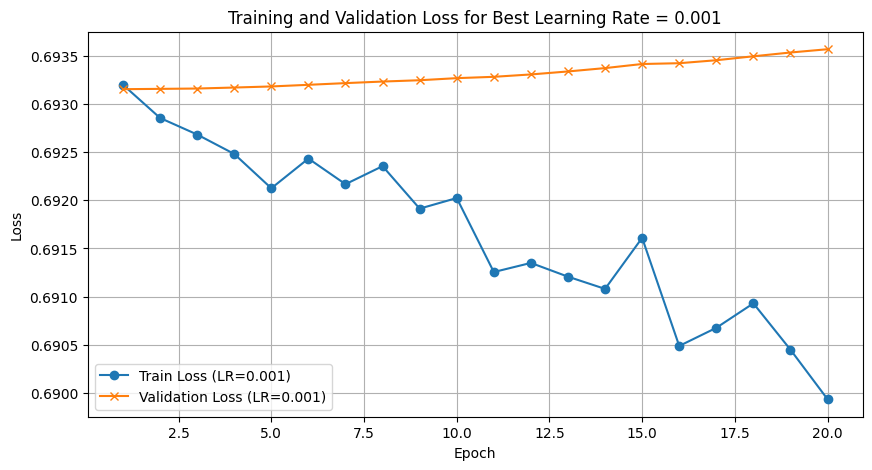

Accuracy of the model on the test images: 56.67%


In [30]:
best_lr = 1e-3 # From the analysis
num_epochs_final_train = 20 # Train for more epochs with the best LR for better convergence

print(f"Training final model with best learning rate: {best_lr}")

# Initialize model and components for the best learning rate
final_model = NewLogisticRegression()
with torch.no_grad():
  for layer in final_model.modules():
      if isinstance(layer, nn.Linear):
          layer.weight.zero_()
          layer.bias.zero_()

final_criterion = nn.BCEWithLogitsLoss() # Appropriate for binary classification with logits output
final_optimizer = optim.AdamW(final_model.parameters(), lr=best_lr)

final_train_losses = []
final_val_losses = []

for epoch in range(num_epochs_final_train):
  final_model.train() # Set model to training mode
  epoch_train_losses = []
  for X_train, y_train in train_loader:
    y_hat_train = final_model(X_train).squeeze(1)
    y_train = y_train.to(torch.float32)
    loss = final_criterion(y_hat_train, y_train)
    epoch_train_losses.append(loss.item())

    final_optimizer.zero_grad()
    loss.backward()
    final_optimizer.step()
  final_train_losses.append(np.mean(epoch_train_losses))

  final_model.eval() # Set model to evaluation mode
  epoch_val_losses = []
  with torch.no_grad():
    for X_val, y_val in val_loader:
      y_hat_val = final_model(X_val).squeeze(1)
      y_val = y_val.to(torch.float32)
      val_loss = final_criterion(y_hat_val, y_val)
      epoch_val_losses.append(val_loss.item())
  final_val_losses.append(np.mean(epoch_val_losses))

  print(f"Epoch {epoch+1}/{num_epochs_final_train}, Train Loss: {final_train_losses[-1]:.4f}, Val Loss: {final_val_losses[-1]:.4f}")

print("Final model training complete.")

# Plot the final training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs_final_train + 1), final_train_losses, label=f'Train Loss (LR={best_lr})', marker='o')
plt.plot(range(1, num_epochs_final_train + 1), final_val_losses, label=f'Validation Loss (LR={best_lr})', marker='x')
plt.title(f'Training and Validation Loss for Best Learning Rate = {best_lr}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Evaluate on the test set and compute accuracy
final_model.eval()
correct = 0
total = 0
all_y_pred = []
all_y_true = []
all_X_test = []

with torch.no_grad():
    for X_test, y_test in test_loader:
        y_hat_test = final_model(X_test).squeeze(1)
        predicted = (y_hat_test > 0).float() # Threshold at 0 for BCEWithLogitsLoss output (sigmoid(0)=0.5)
        total += y_test.size(0)
        correct += (predicted == y_test).sum().item()
        all_y_pred.extend(predicted.tolist())
        all_y_true.extend(y_test.tolist())
        all_X_test.append(X_test)

accuracy = 100 * correct / total
print(f'Accuracy of the model on the test images: {accuracy:.2f}%')


Number of incorrectly classified images: 13
Displaying incorrectly classified images:


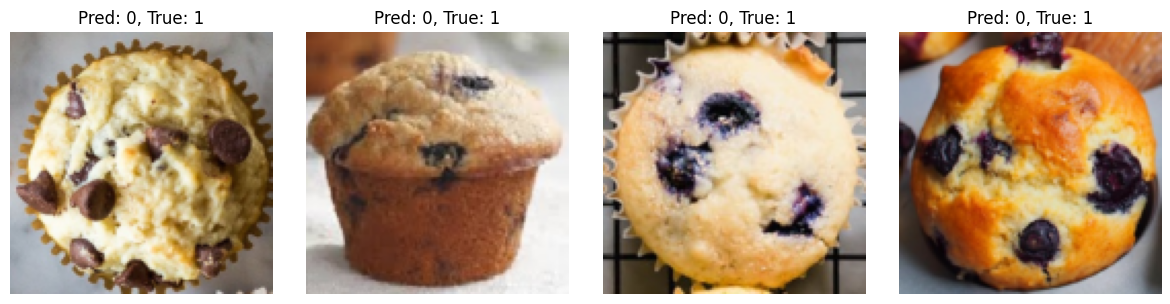

In [31]:
incorrect_indices = [i for i, (pred, true) in enumerate(zip(all_y_pred, all_y_true)) if pred != true]

print(f"Number of incorrectly classified images: {len(incorrect_indices)}")

# Display up to 4 incorrectly classified images
num_to_display = min(4, len(incorrect_indices))

if num_to_display > 0:
    fig, axes = plt.subplots(1, num_to_display, figsize=(3 * num_to_display, 3))
    if num_to_display == 1:
        axes = [axes] # Make it iterable for consistency

    print("Displaying incorrectly classified images:")
    for i in range(num_to_display):
        idx = incorrect_indices[i]
        # The image data is stored as a list of tensors, where each tensor is a batch.
        # Since test_loader has batch_size=len(test_dataset), all_X_test will have one element.
        image_tensor = all_X_test[0][idx] # Get the specific image tensor
        # Convert from (C, H, W) to (H, W, C) for matplotlib
        image = image_tensor.permute(1, 2, 0).numpy()
        axes[i].imshow(image)
        axes[i].set_title(f"Pred: {int(all_y_pred[idx])}, True: {int(all_y_true[idx])}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No incorrectly classified images to display.")
